In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

df = pd.read_csv(
    "Desktop/Sample - Superstore.csv",
    encoding="cp1252"
)

print(df.shape)
print(df.head())

(9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       4

In [9]:
print(df.columns.tolist())
print(df.info())
print(df.isnull().sum())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region      

In [11]:
# Check dataset size
print("Dataset shape:", df.shape)

# Check column names
print(df.columns.tolist())

# Check missing values
print(df.isnull().sum())

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check data types
df.info()

Dataset shape: (9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 

In [16]:
# Check missing values
print(df.isnull().sum())

# Check duplicate rows
print("Duplicates:", df.duplicated().sum())

# Remove exact duplicate rows
df = df.drop_duplicates()

# Convert date columns
df["Order Date"] = pd.to_datetime(
    df["Order Date"], errors="coerce"
)

# Remove records without essential analysis fields
df = df.dropna(
    subset=["Order Date", "Sales", "Profit"]
)

# Check numerical columns
print(df[["Sales", "Profit", "Quantity", "Discount"]].describe())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicates: 0
              Sales       Profit     Quantity     Discount
count   9994.000000  9994.000000  9994.000000  9994.000000
mean     229.858001    28.656896     3.789574     0.156203
std      623.245101   234.260108     2.225110     0.206452
min        0.444000 -6599.978000     1.000000     0.000000
25%       17.280000     1.728750     2.000000     0.000000
50%       54.490000     8.666500     3.000000     0.200000
75%      209.940000    29.364000     5.000000     0.200000
max    22638.480000  8399.976000    14.000000     0.800000


In [18]:
df["Order Month"] = (
    df["Order Date"].dt.to_period("M").astype(str)
)

df["Order Year"] = df["Order Date"].dt.year

df["Profit Margin"] = np.where(
    df["Sales"] != 0,
    df["Profit"] / df["Sales"] * 100,
    np.nan
)

In [20]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()

profit_margin = (
    total_profit / total_sales * 100
    if total_sales != 0 else np.nan
)

average_order_value = (
    total_sales / total_orders
    if total_orders != 0 else np.nan
)

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Profit Margin:", round(profit_margin, 2), "%")
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))

Total Sales: 2297200.86
Total Profit: 286397.02
Profit Margin: 12.47 %
Total Orders: 5009
Average Order Value: 458.61


In [22]:
category_analysis = (
    df.groupby("Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .reset_index()
)

category_analysis["Profit Margin %"] = (
    category_analysis["Profit"]
    / category_analysis["Sales"] * 100
)

print(category_analysis.sort_values("Profit", ascending=False))

          Category        Sales       Profit  Quantity  Profit Margin %
2       Technology  836154.0330  145454.9481      6939        17.395712
1  Office Supplies  719047.0320  122490.8008     22906        17.035158
0        Furniture  741999.7953   18451.2728      8028         2.486695


In [24]:
product_analysis = (
    df.groupby(["Product ID", "Product Name"])
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .reset_index()
)

product_analysis["Profit Margin %"] = (
    product_analysis["Profit"]
    / product_analysis["Sales"].replace(0, np.nan)
    * 100
)

loss_products = product_analysis[
    product_analysis["Profit"] < 0
].sort_values("Profit")

print(loss_products.head(20))

           Product ID                                       Product Name  \
1645  TEC-MA-10000418          Cubify CubeX 3D Printer Double Head Print   
1650  TEC-MA-10000822          Lexmark MX611dhe Monochrome Laser Printer   
1696  TEC-MA-10004125          Cubify CubeX 3D Printer Triple Head Print   
326   FUR-TA-10000198  Chromcraft Bull-Nose Wood Oval Conference Tabl...   
344   FUR-TA-10001889  Bush Advantage Collection Racetrack Conference...   
858   OFF-BI-10004995          GBC DocuBind P400 Electric Binding System   
1669  TEC-MA-10002412  Cisco TelePresence System EX90 Videoconferenci...   
1465  OFF-SU-10002881  Martin Yale Chadless Opener Electric Letter Op...   
346   FUR-TA-10001950                       Balt Solid Wood Round Tables   
375   FUR-TA-10004289  BoxOffice By Design Rectangular and Half-Moon ...   
372   FUR-TA-10004154  Riverside Furniture Oval Coffee Table, Oval En...   
1668  TEC-MA-10002210  Epson TM-T88V Direct Thermal Printer - Monochr...   
105   FUR-CH

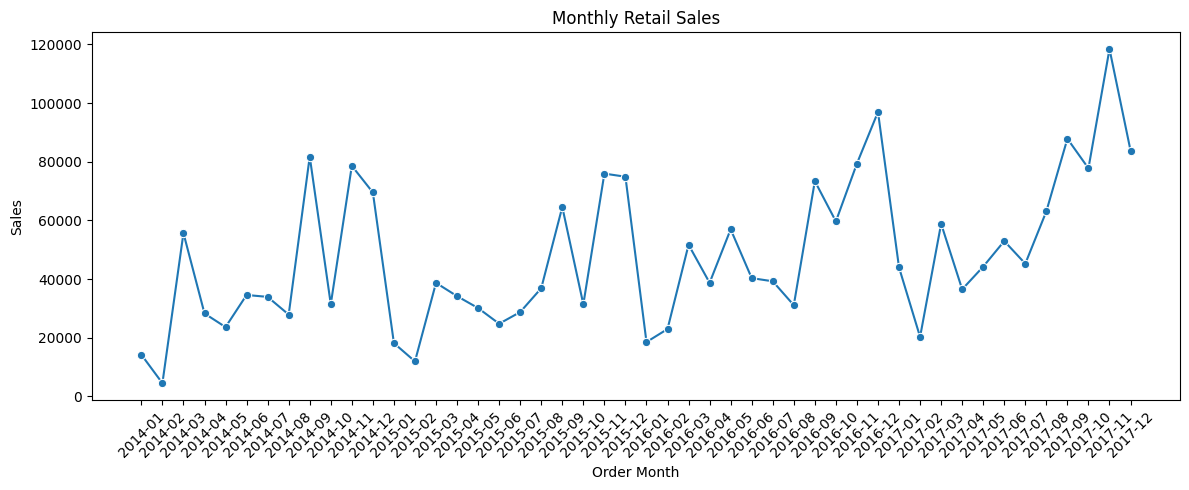

In [26]:
monthly = (
    df.groupby("Order Month")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly,
    x="Order Month",
    y="Sales",
    marker="o"
)
plt.xticks(rotation=45)
plt.title("Monthly Retail Sales")
plt.tight_layout()
plt.show()

In [28]:
import sqlite3

conn = sqlite3.connect("retail_sales.db")

df.to_sql(
    "retail_sales",
    conn,
    if_exists="replace",
    index=False
)

print("Table created successfully!")

Table created successfully!


In [30]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print(tables)

           name
0  retail_sales


In [32]:
result = pd.read_sql_query(
    "SELECT * FROM retail_sales LIMIT 5;",
    conn
)

print(result)

   Row ID        Order ID           Order Date   Ship Date       Ship Mode  \
0       1  CA-2016-152156  2016-11-08 00:00:00  11/11/2016    Second Class   
1       2  CA-2016-152156  2016-11-08 00:00:00  11/11/2016    Second Class   
2       3  CA-2016-138688  2016-06-12 00:00:00   6/16/2016    Second Class   
3       4  US-2015-108966  2015-10-11 00:00:00  10/18/2015  Standard Class   
4       5  US-2015-108966  2015-10-11 00:00:00  10/18/2015  Standard Class   

  Customer ID    Customer Name    Segment        Country             City  \
0    CG-12520      Claire Gute   Consumer  United States        Henderson   
1    CG-12520      Claire Gute   Consumer  United States        Henderson   
2    DV-13045  Darrin Van Huff  Corporate  United States      Los Angeles   
3    SO-20335   Sean O'Donnell   Consumer  United States  Fort Lauderdale   
4    SO-20335   Sean O'Donnell   Consumer  United States  Fort Lauderdale   

   ...         Category  Sub-Category  \
0  ...        Furniture    

In [26]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly = (
    df.groupby(df["Order Date"].dt.to_period("M"))
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

monthly["Order Date"] = monthly["Order Date"].dt.to_timestamp()

monthly.head()

,Order Date,Sales,Profit
0,2014-01-01,14236.895,2450.1907
1,2014-02-01,4519.892,862.3084
2,2014-03-01,55691.009,498.7299
3,2014-04-01,28295.345,3488.8352
4,2014-05-01,23648.287,2738.7096


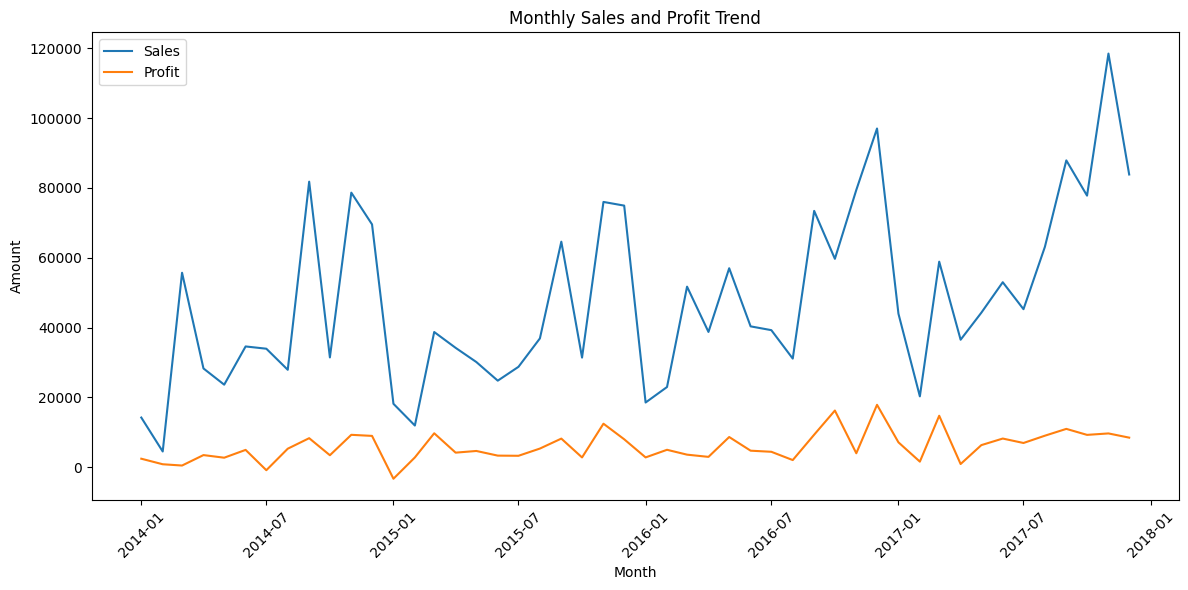

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly["Order Date"],
    monthly["Sales"],
    label="Sales"
)

plt.plot(
    monthly["Order Date"],
    monthly["Profit"],
    label="Profit"
)

plt.title("Monthly Sales and Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

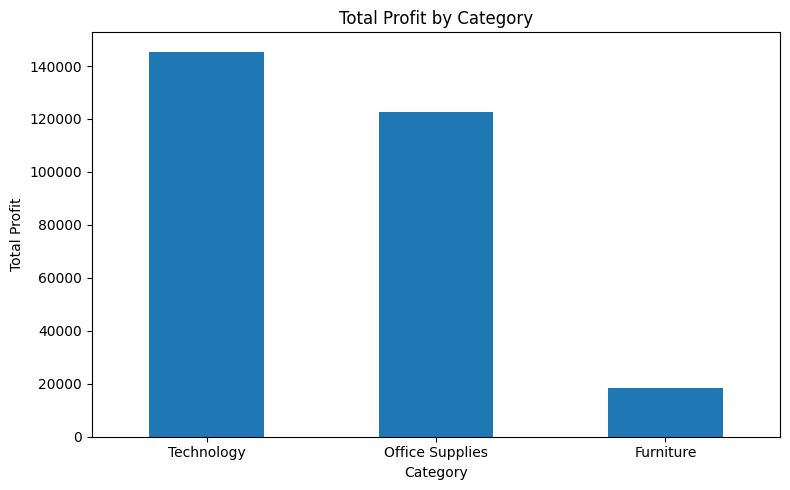

In [30]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

category_profit.plot(kind="bar")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

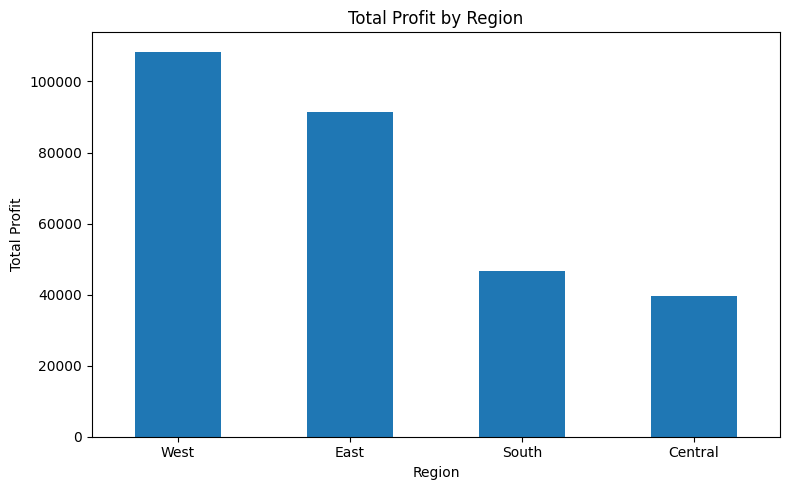

In [32]:
region_profit = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

region_profit.plot(kind="bar")

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

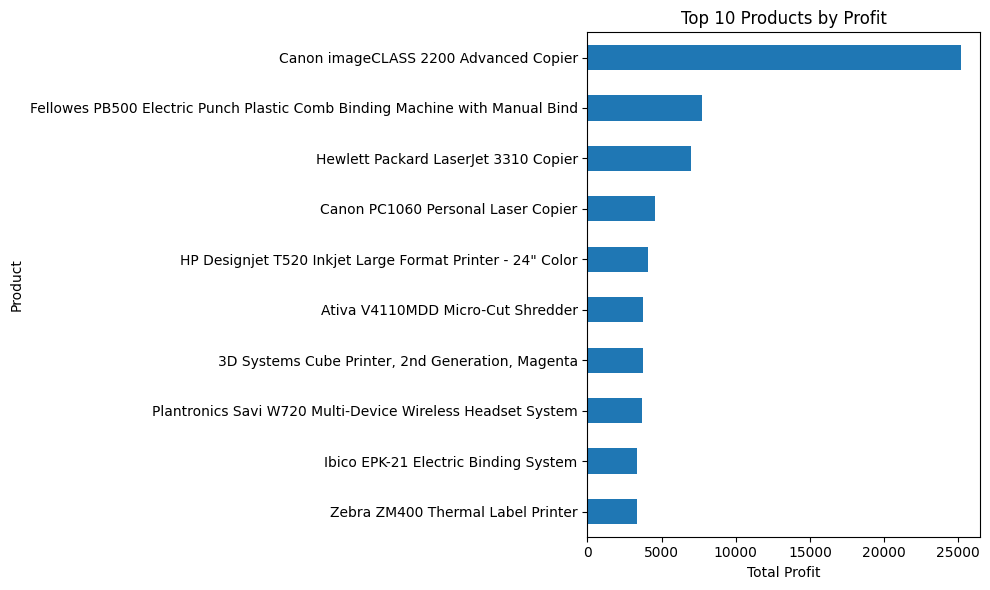

In [34]:
product_profit = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

top_10 = product_profit.head(10)

plt.figure(figsize=(10, 6))

top_10.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

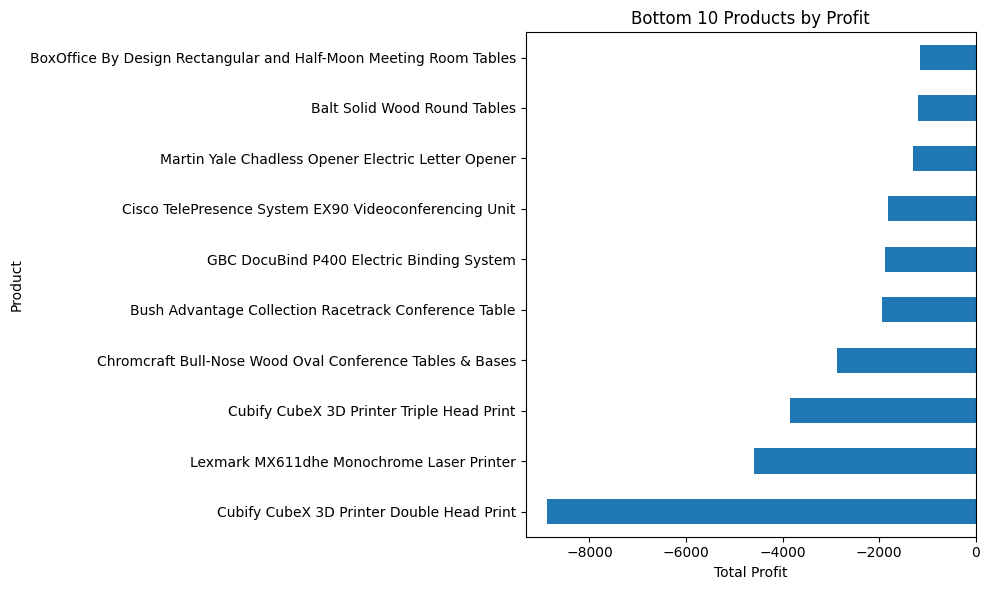

In [36]:
bottom_10 = product_profit.tail(10)

plt.figure(figsize=(10, 6))

bottom_10.sort_values().plot(kind="barh")

plt.title("Bottom 10 Products by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [38]:
discount_analysis = (
    df.groupby("Discount")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

discount_analysis["Profit_Margin"] = (
    discount_analysis["Profit"] /
    discount_analysis["Sales"] * 100
)

discount_analysis

,Discount,Sales,Profit,Profit_Margin
0,0.00,1.087908e+06,320987.6032,29.505019
1,0.10,5.436935e+04,9029.1770,16.607108
2,0.15,2.755852e+04,1418.9915,5.149012
3,0.20,7.645944e+05,90337.3060,11.815063
4,0.30,1.032267e+05,-10369.2774,-10.045155
5,0.32,1.449346e+04,-2391.1377,-16.498047
6,0.40,1.164178e+05,-23057.0504,-19.805437
7,0.45,5.484974e+03,-2493.1111,-45.453472
8,0.50,5.891854e+04,-20506.4281,-34.804712
9,0.60,6.644700e+03,-5944.6552,-89.464614


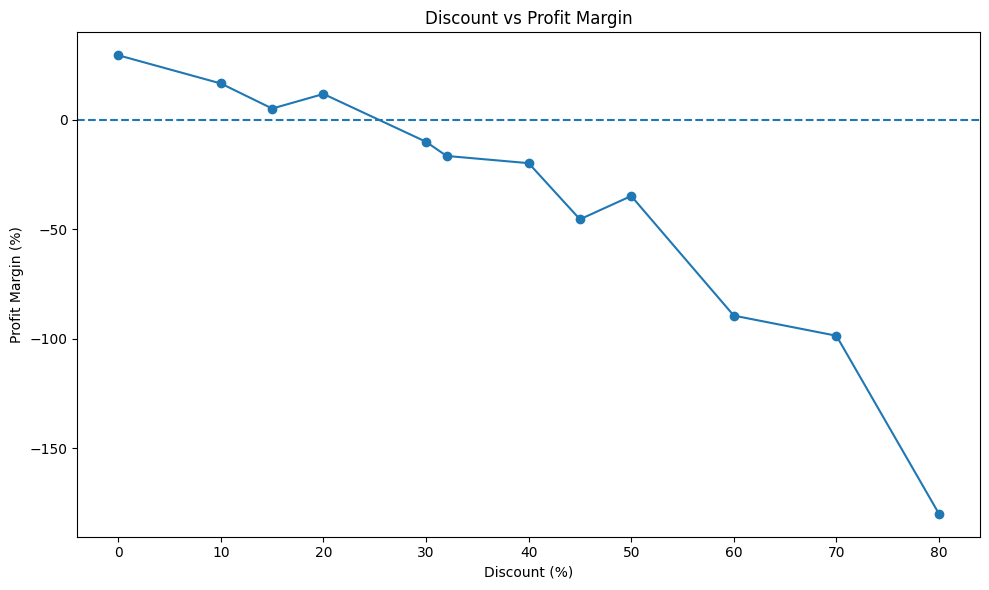

In [40]:
plt.figure(figsize=(10, 6))

plt.plot(
    discount_analysis["Discount"] * 100,
    discount_analysis["Profit_Margin"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Discount vs Profit Margin")
plt.xlabel("Discount (%)")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()

plt.show()

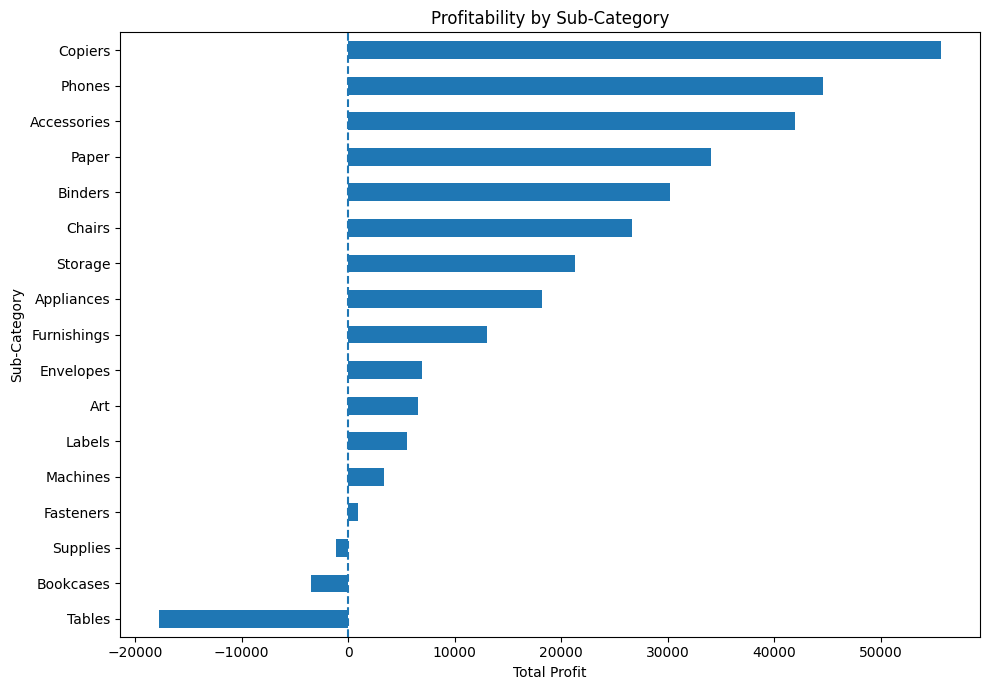

In [42]:
subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(10, 7))

subcategory_profit.plot(kind="barh")

plt.axvline(0, linestyle="--")

plt.title("Profitability by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

In [44]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = (total_profit / total_sales) * 100
total_orders = df["Order ID"].nunique()
average_order_value = total_sales / total_orders

product_profit = df.groupby("Product Name")["Profit"].sum()
loss_making_products = (product_profit < 0).sum()

print("===== RETAIL SALES & PROFITABILITY KPIs =====")
print(f"Total Sales: ₹{total_sales:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Loss-Making Products: {loss_making_products}")

===== RETAIL SALES & PROFITABILITY KPIs =====
Total Sales: ₹2,297,200.86
Total Profit: ₹286,397.02
Profit Margin: 12.47%
Total Orders: 5,009
Average Order Value: ₹458.61
Loss-Making Products: 301


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6512\3831155195.py:112: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


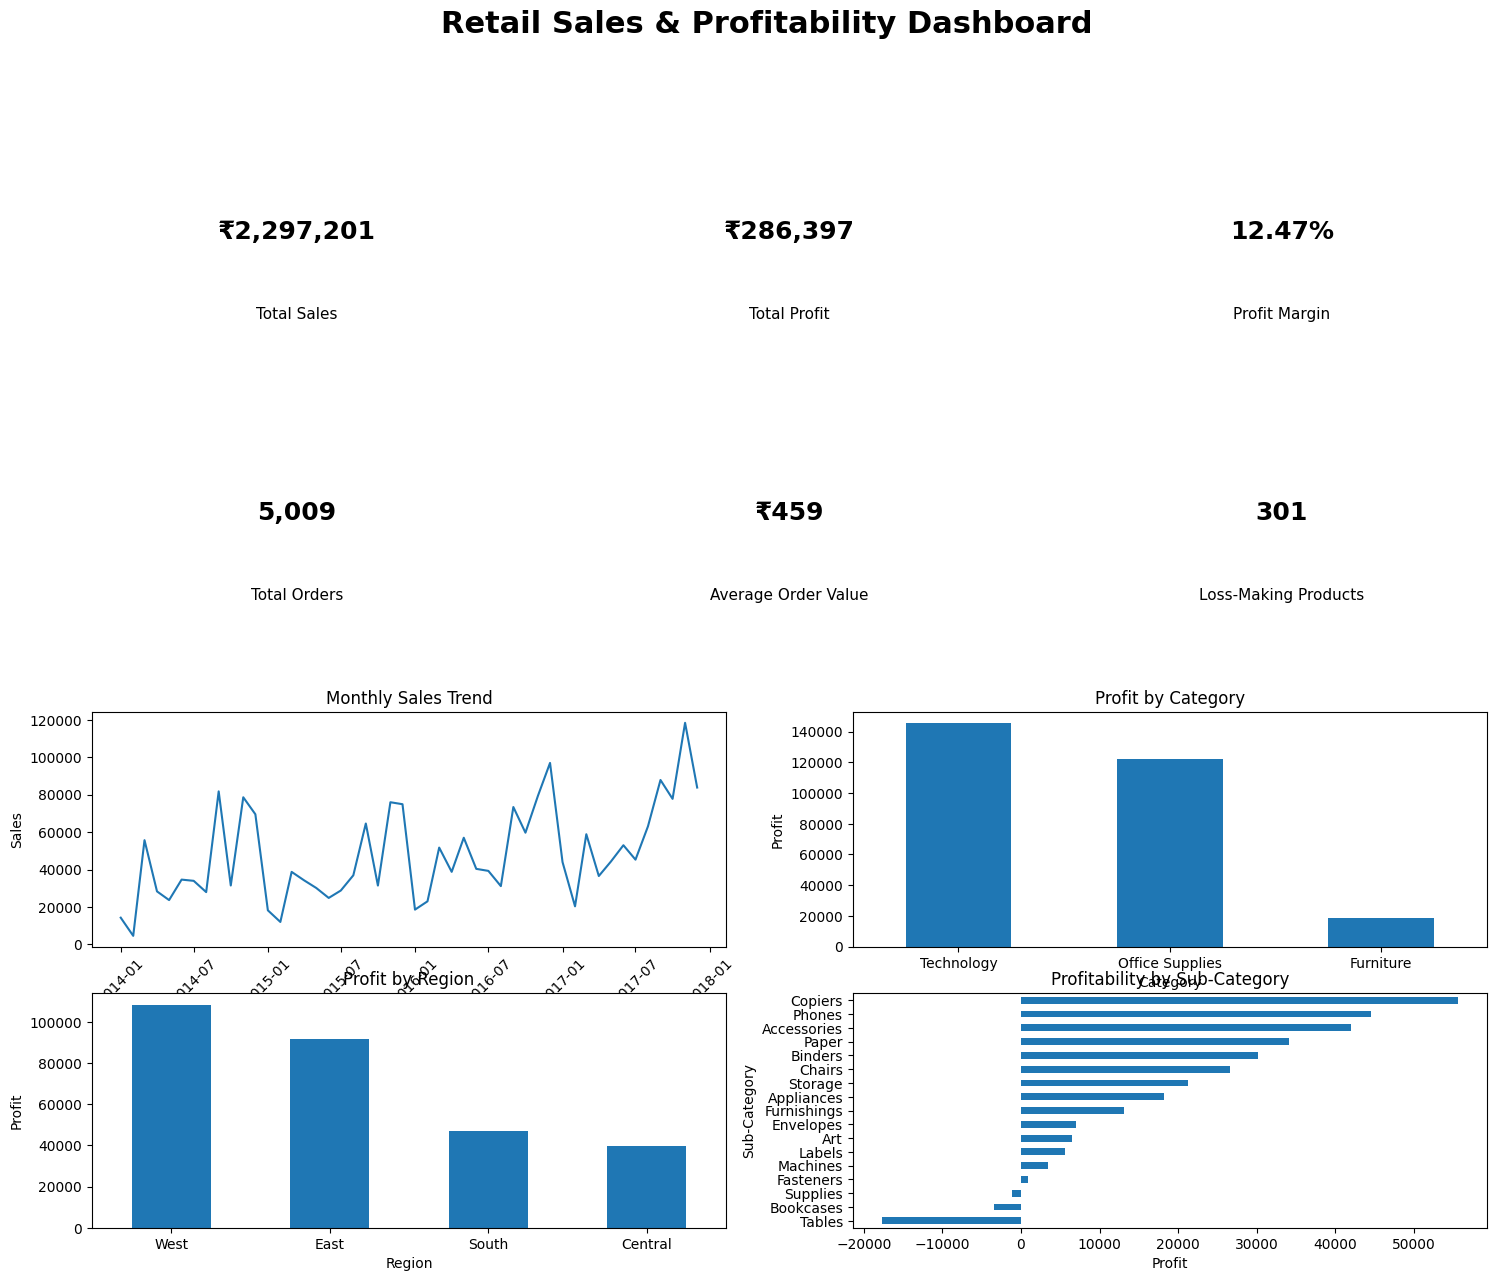

In [46]:
fig = plt.figure(figsize=(18, 14))

# ---------- KPI DATA ----------
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = (total_profit / total_sales) * 100
total_orders = df["Order ID"].nunique()
average_order_value = total_sales / total_orders

product_profit = df.groupby("Product Name")["Profit"].sum()
loss_making_products = (product_profit < 0).sum()

# ---------- DASHBOARD TITLE ----------
fig.suptitle(
    "Retail Sales & Profitability Dashboard",
    fontsize=22,
    fontweight="bold",
    y=0.98
)

# ---------- KPI CARDS ----------
kpis = [
    ("Total Sales", f"₹{total_sales:,.0f}"),
    ("Total Profit", f"₹{total_profit:,.0f}"),
    ("Profit Margin", f"{profit_margin:.2f}%"),
    ("Total Orders", f"{total_orders:,}"),
    ("Average Order Value", f"₹{average_order_value:,.0f}"),
    ("Loss-Making Products", f"{loss_making_products}")
]

for i, (title, value) in enumerate(kpis):
    ax = fig.add_subplot(4, 3, i + 1)
    ax.axis("off")

    ax.text(
        0.5, 0.65,
        value,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.30,
        title,
        ha="center",
        va="center",
        fontsize=11
    )

# ---------- MONTHLY SALES ----------
ax7 = fig.add_subplot(4, 2, 5)

monthly = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
)

monthly.index = monthly.index.to_timestamp()

ax7.plot(monthly.index, monthly.values)
ax7.set_title("Monthly Sales Trend")
ax7.set_xlabel("Month")
ax7.set_ylabel("Sales")
ax7.tick_params(axis="x", rotation=45)

# ---------- CATEGORY PROFIT ----------
ax8 = fig.add_subplot(4, 2, 6)

category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit.plot(kind="bar", ax=ax8)
ax8.set_title("Profit by Category")
ax8.set_xlabel("Category")
ax8.set_ylabel("Profit")
ax8.tick_params(axis="x", rotation=0)

# ---------- REGION PROFIT ----------
ax9 = fig.add_subplot(4, 2, 7)

region_profit = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

region_profit.plot(kind="bar", ax=ax9)
ax9.set_title("Profit by Region")
ax9.set_xlabel("Region")
ax9.set_ylabel("Profit")
ax9.tick_params(axis="x", rotation=0)

# ---------- SUB-CATEGORY PROFIT ----------
ax10 = fig.add_subplot(4, 2, 8)

subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values()
)

subcategory_profit.plot(kind="barh", ax=ax10)
ax10.set_title("Profitability by Sub-Category")
ax10.set_xlabel("Profit")
ax10.set_ylabel("Sub-Category")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [48]:
df["Order Date"].dt.to_period("M")

0       2016-11
1       2016-11
2       2016-06
3       2015-10
4       2015-10
         ...   
9989    2014-01
9990    2017-02
9991    2017-02
9992    2017-02
9993    2017-05
Name: Order Date, Length: 9994, dtype: period[M]

In [50]:
plt.savefig(
    "retail_sales_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [52]:
plt.savefig(
    "retail_sales_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [54]:
import os

print(os.path.abspath("retail_sales_dashboard.png"))

C:\Users\Lenovo\retail_sales_dashboard.png


In [56]:
# ==============================
# BUSINESS INSIGHTS
# ==============================

# 1. Category performance
category_summary = (
    df.groupby("Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_values("Profit", ascending=False)
)

# 2. Region performance
region_summary = (
    df.groupby("Region")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_values("Profit", ascending=False)
)

# 3. Sub-category performance
subcategory_summary = (
    df.groupby("Sub-Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_values("Profit")
)

# 4. Discount analysis
discount_summary = (
    df.groupby("Discount")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

discount_summary["Profit_Margin"] = (
    discount_summary["Profit"] /
    discount_summary["Sales"] * 100
)

# 5. Product performance
product_summary = (
    df.groupby("Product Name")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_values("Profit")
)

print("===== CATEGORY PERFORMANCE =====")
display(category_summary)

print("\n===== REGION PERFORMANCE =====")
display(region_summary)

print("\n===== LOWEST PROFIT SUB-CATEGORIES =====")
display(subcategory_summary.head(10))

print("\n===== DISCOUNT & PROFITABILITY =====")
display(discount_summary)

print("\n===== LOWEST PROFIT PRODUCTS =====")
display(product_summary.head(10))

===== CATEGORY PERFORMANCE =====


,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Office Supplies,719047.0320,122490.8008
Furniture,741999.7953,18451.2728



===== REGION PERFORMANCE =====


,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
South,391721.9050,46749.4303
Central,501239.8908,39706.3625



===== LOWEST PROFIT SUB-CATEGORIES =====


,Sales,Profit
Sub-Category,,
Tables,206965.5320,-17725.4811
Bookcases,114879.9963,-3472.5560
Supplies,46673.5380,-1189.0995
Fasteners,3024.2800,949.5182
Machines,189238.6310,3384.7569
Labels,12486.3120,5546.2540
Art,27118.7920,6527.7870
Envelopes,16476.4020,6964.1767
Furnishings,91705.1640,13059.1436



===== DISCOUNT & PROFITABILITY =====


,Discount,Sales,Profit,Profit_Margin
0,0.00,1.087908e+06,320987.6032,29.505019
1,0.10,5.436935e+04,9029.1770,16.607108
2,0.15,2.755852e+04,1418.9915,5.149012
3,0.20,7.645944e+05,90337.3060,11.815063
4,0.30,1.032267e+05,-10369.2774,-10.045155
5,0.32,1.449346e+04,-2391.1377,-16.498047
6,0.40,1.164178e+05,-23057.0504,-19.805437
7,0.45,5.484974e+03,-2493.1111,-45.453472
8,0.50,5.891854e+04,-20506.4281,-34.804712
9,0.60,6.644700e+03,-5944.6552,-89.464614



===== LOWEST PROFIT PRODUCTS =====


,Sales,Profit
Product Name,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836
Balt Solid Wood Round Tables,6518.754,-1201.0581
